# **Final Project**

## **Preprocessing/EDA**

In [ ]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# create dataframe
df = pd.read_csv('StudentPerformanceFactors.csv')
pd.set_option('display.max_columns', None)

Exploratory Data Analysis

In [ ]:
df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [ ]:
# 6607 rows, 20 columns
df.shape

(6607, 20)

In [ ]:
# ints and objects
# Some missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6529 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence              6607 non-null   obje

In [ ]:
# numerical value stats
df.describe()

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235659
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.890456
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000


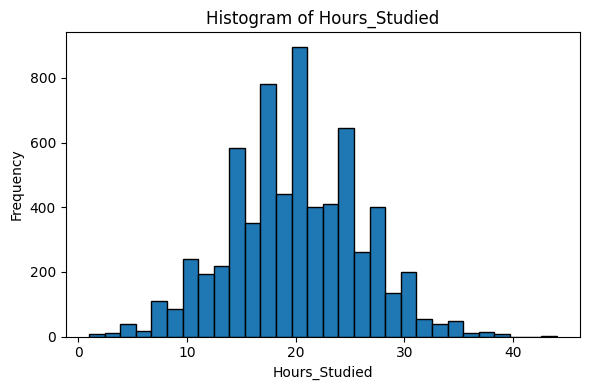

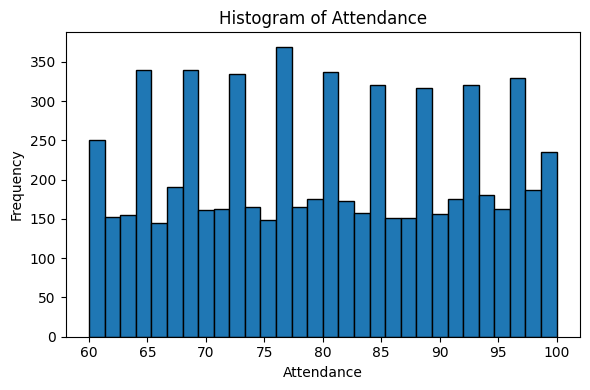

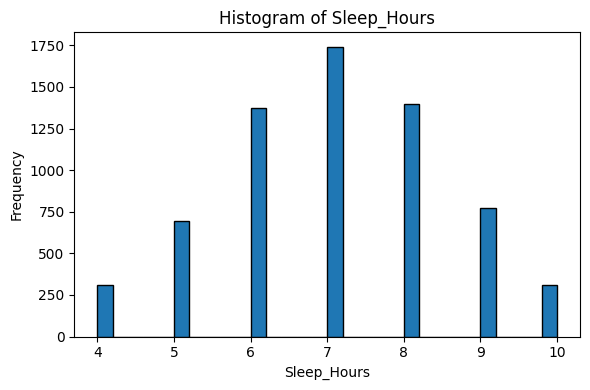

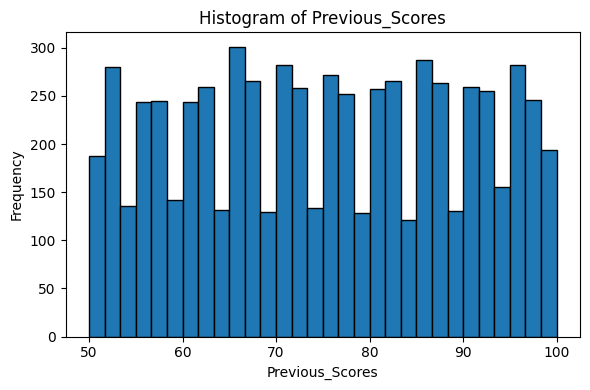

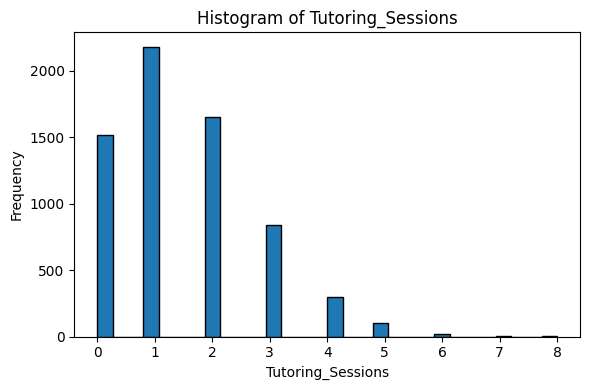

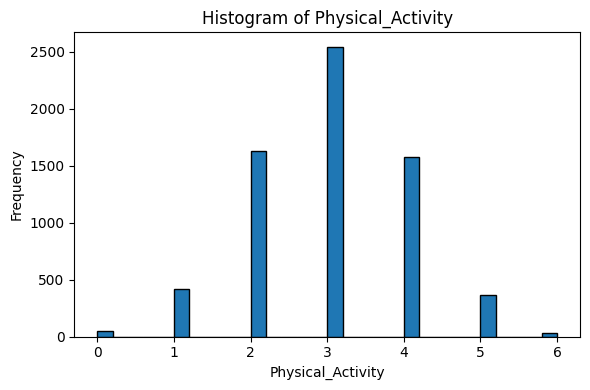

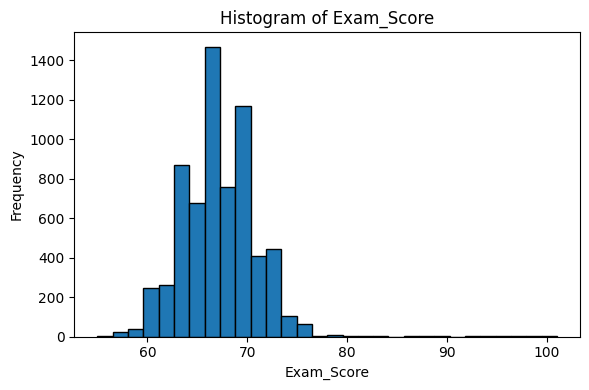

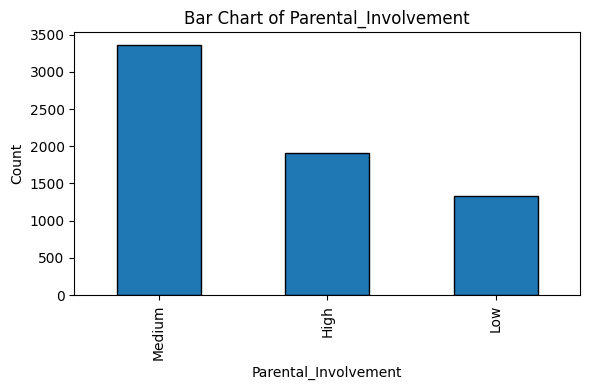

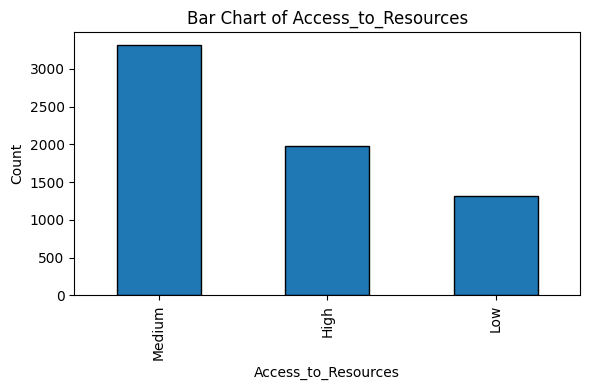

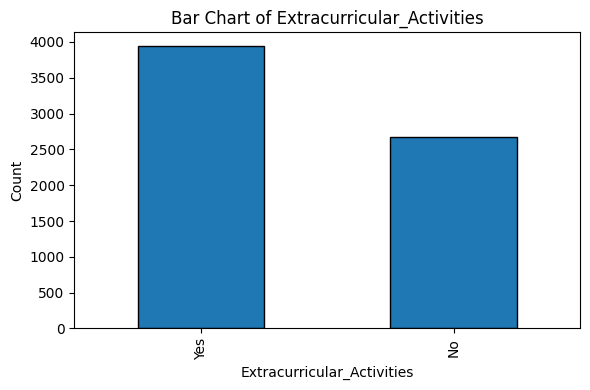

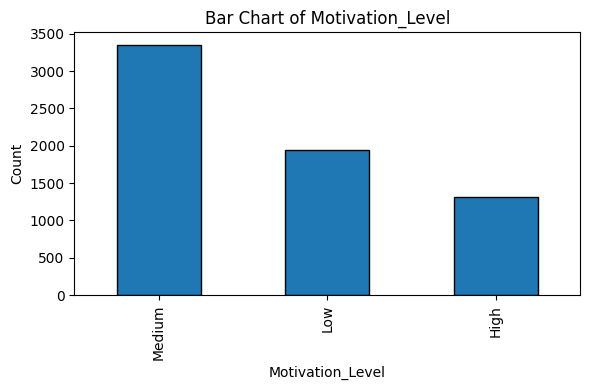

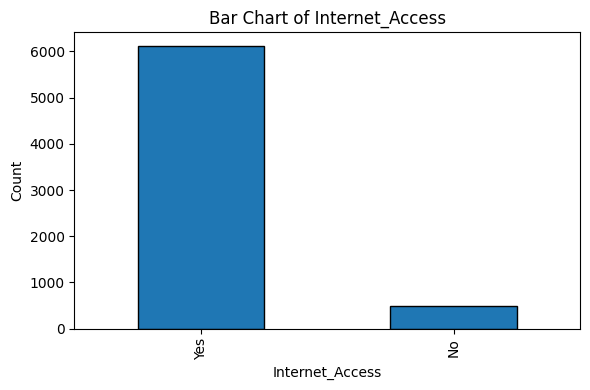

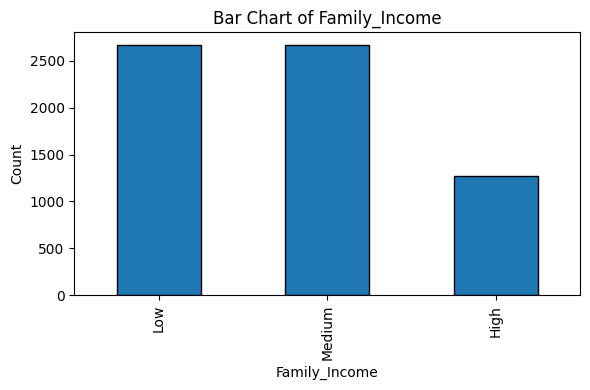

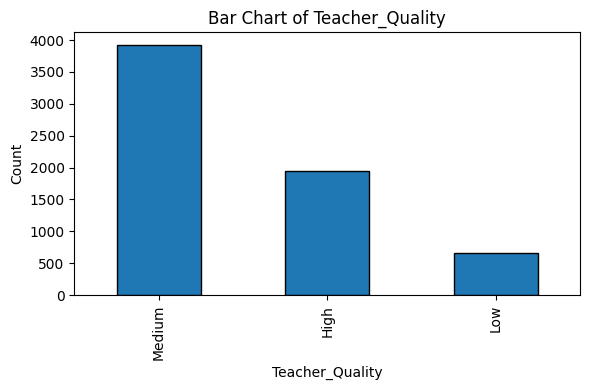

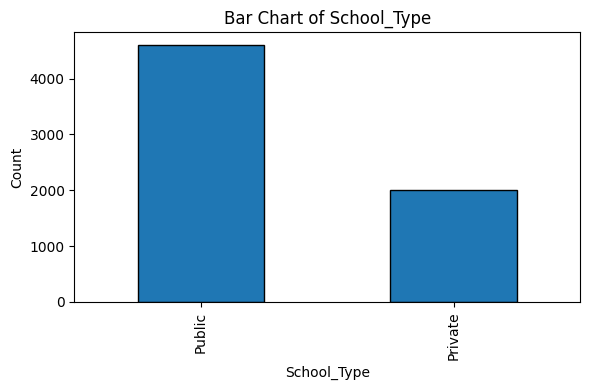

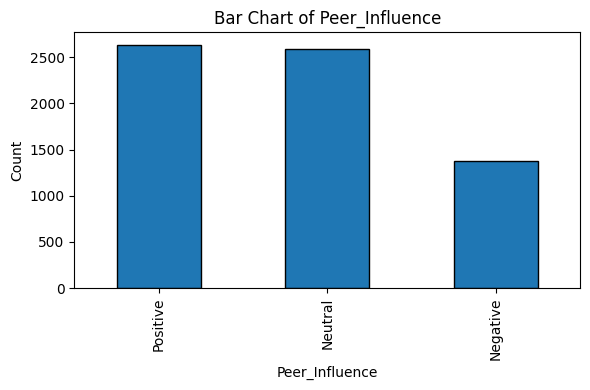

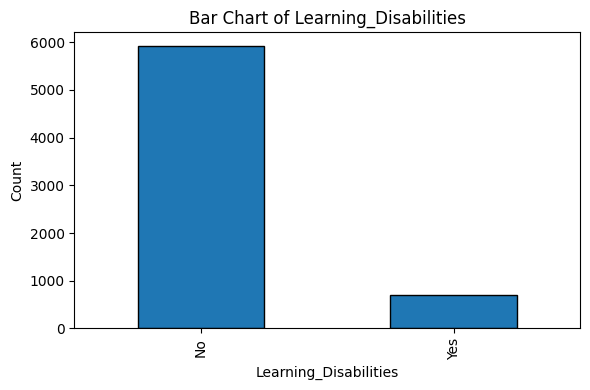

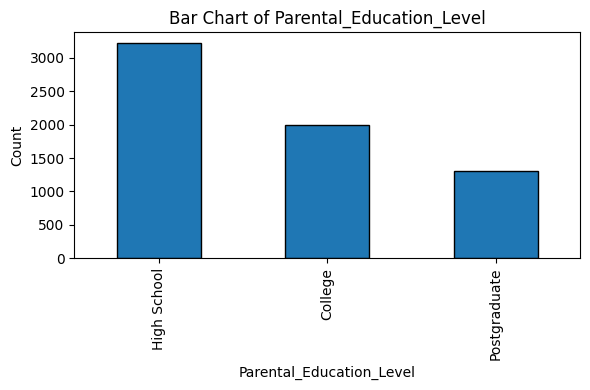

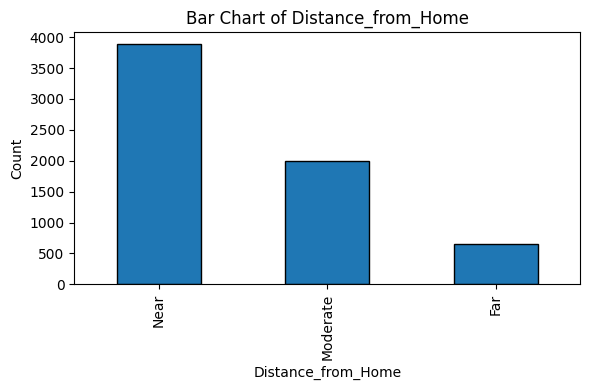

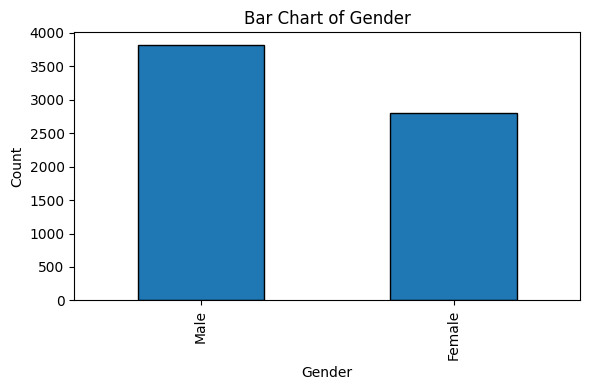

In [ ]:
# visualizations of data
num_cols = df.select_dtypes(include='number').columns
cat_cols = df.select_dtypes(include='object').columns

# histograms for numerical variables, checking distribution and skew
for col in num_cols:
    plt.figure(figsize=(6, 4))
    plt.hist(df[col], bins=30, edgecolor='black')
    plt.title(f'Histogram of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()

# bar charts for categorical variables
for col in cat_cols:
    plt.figure(figsize=(6, 4))
    df[col].value_counts().plot(kind='bar', edgecolor='black')
    plt.title(f'Bar Chart of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.tight_layout()
    plt.show()

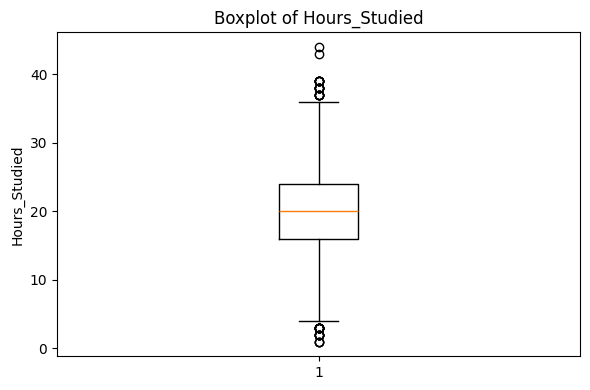

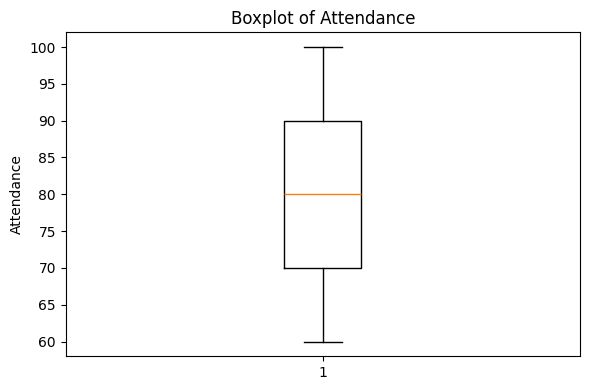

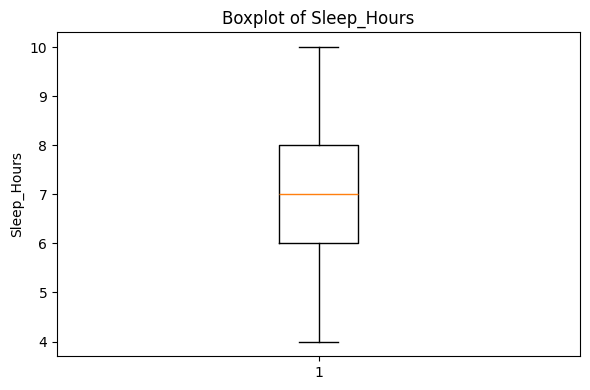

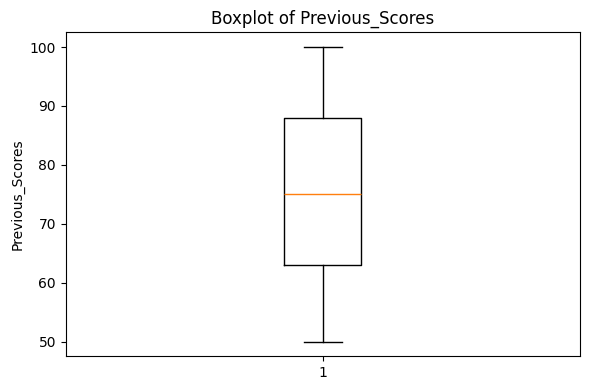

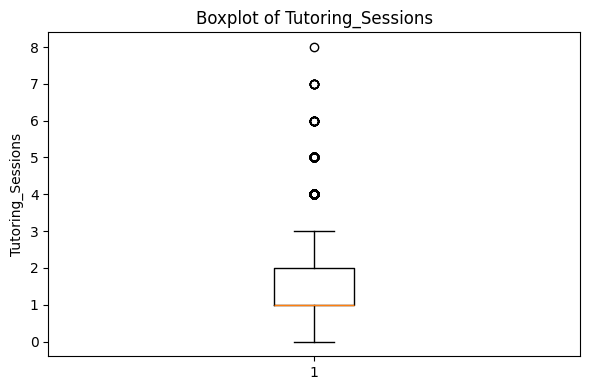

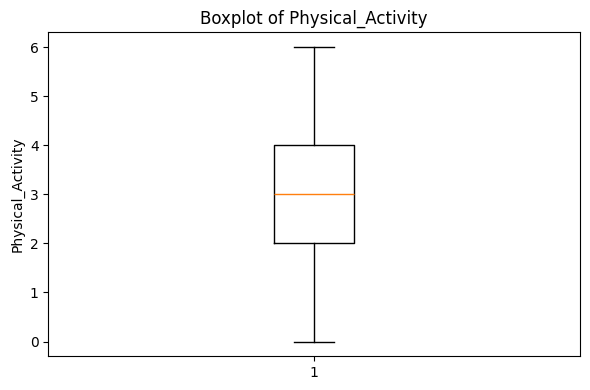

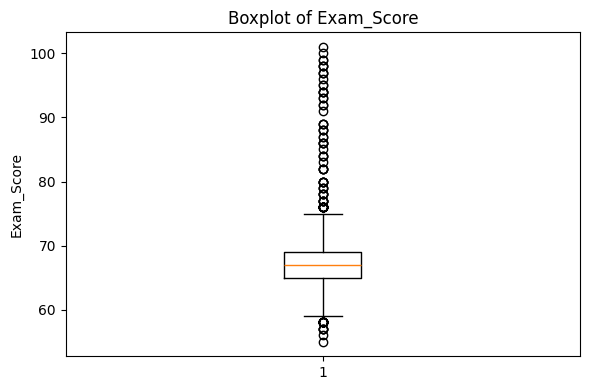

In [ ]:
# boxplots to check outliers in numeric variables
# some in hours studied, exam score, and tutoring sessions
for col in num_cols:
    plt.figure(figsize=(6, 4))
    plt.boxplot(df[col])
    plt.title(f'Boxplot of {col}')
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

Address Missing Values:

In [ ]:
# total null values per column
df.isnull().sum()

,0
Hours_Studied,0
Attendance,0
Parental_Involvement,0
Access_to_Resources,0
Extracurricular_Activities,0
Sleep_Hours,0
Previous_Scores,0
Motivation_Level,0
Internet_Access,0
Tutoring_Sessions,0


In [ ]:
# not many missing, just going to drop the rows
df_clean = df.dropna()

In [ ]:
# new shape
df_clean.shape

(6378, 20)

Encode Categorical Values

In [ ]:
# map categorical values with a hierarchy
ord_maps = {
    'Parental_Involvement': {'Low': 0, 'Medium': 1, 'High': 2},
    'Access_to_Resources': {'Low': 0, 'Medium': 1, 'High': 2},
    'Motivation_Level': {'Low': 0, 'Medium': 1, 'High': 2},
    'Family_Income': {'Low': 0, 'Medium': 1, 'High': 2},
    'Teacher_Quality': {'Low': 0, 'Medium': 1, 'High': 2},
    'Distance_from_Home': {'Near': 0, 'Moderate': 1, 'Far': 2},
    'Parental_Education_Level': {'High School': 0, 'College': 1, 'Postgraduate': 2}
}

for col, mapping in ord_maps.items():
    df_clean[col] = df_clean[col].map(mapping)

/tmp/ipykernel_551/2627574365.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean[col] = df_clean[col].map(mapping)
/tmp/ipykernel_551/2627574365.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean[col] = df_clean[col].map(mapping)
/tmp/ipykernel_551/2627574365.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-doc

In [ ]:
df_clean.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,0,2,No,7,73,0,Yes,0,0,1,Public,Positive,3,No,0,0,Male,67
1,19,64,0,1,No,8,59,0,Yes,2,1,1,Public,Negative,4,No,1,1,Female,61
2,24,98,1,1,Yes,7,91,1,Yes,2,1,1,Public,Neutral,4,No,2,0,Male,74
3,29,89,0,1,Yes,8,98,1,Yes,1,1,1,Public,Negative,4,No,0,1,Male,71
4,19,92,1,1,Yes,6,65,1,Yes,3,1,2,Public,Neutral,4,No,1,0,Female,70


In [ ]:
# dummy encode non-hierarchical categorical variables
df_clean = pd.get_dummies(df_clean, columns=[
    'Extracurricular_Activities',
    'Internet_Access',
    'School_Type',
    'Peer_Influence',
    'Learning_Disabilities',
    'Gender'
], dtype=int)

In [ ]:
# new df columns
df_clean.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Sleep_Hours,Previous_Scores,Motivation_Level,Tutoring_Sessions,Family_Income,Teacher_Quality,Physical_Activity,Parental_Education_Level,Distance_from_Home,Exam_Score,Extracurricular_Activities_No,Extracurricular_Activities_Yes,Internet_Access_No,Internet_Access_Yes,School_Type_Private,School_Type_Public,Peer_Influence_Negative,Peer_Influence_Neutral,Peer_Influence_Positive,Learning_Disabilities_No,Learning_Disabilities_Yes,Gender_Female,Gender_Male
0,23,84,0,2,7,73,0,0,0,1,3,0,0,67,1,0,0,1,0,1,0,0,1,1,0,0,1
1,19,64,0,1,8,59,0,2,1,1,4,1,1,61,1,0,0,1,0,1,1,0,0,1,0,1,0
2,24,98,1,1,7,91,1,2,1,1,4,2,0,74,0,1,0,1,0,1,0,1,0,1,0,0,1
3,29,89,0,1,8,98,1,1,1,1,4,0,1,71,0,1,0,1,0,1,1,0,0,1,0,0,1
4,19,92,1,1,6,65,1,3,1,2,4,1,0,70,0,1,0,1,0,1,0,1,0,1,0,1,0


In [ ]:
# all integers now
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6378 entries, 0 to 6606
Data columns (total 27 columns):
 #   Column                          Non-Null Count  Dtype
---  ------                          --------------  -----
 0   Hours_Studied                   6378 non-null   int64
 1   Attendance                      6378 non-null   int64
 2   Parental_Involvement            6378 non-null   int64
 3   Access_to_Resources             6378 non-null   int64
 4   Sleep_Hours                     6378 non-null   int64
 5   Previous_Scores                 6378 non-null   int64
 6   Motivation_Level                6378 non-null   int64
 7   Tutoring_Sessions               6378 non-null   int64
 8   Family_Income                   6378 non-null   int64
 9   Teacher_Quality                 6378 non-null   int64
 10  Physical_Activity               6378 non-null   int64
 11  Parental_Education_Level        6378 non-null   int64
 12  Distance_from_Home              6378 non-null   int64
 13  Exam_Sco

In [ ]:
df_clean.describe()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Sleep_Hours,Previous_Scores,Motivation_Level,Tutoring_Sessions,Family_Income,Teacher_Quality,Physical_Activity,Parental_Education_Level,Distance_from_Home,Exam_Score,Extracurricular_Activities_No,Extracurricular_Activities_Yes,Internet_Access_No,Internet_Access_Yes,School_Type_Private,School_Type_Public,Peer_Influence_Negative,Peer_Influence_Neutral,Peer_Influence_Positive,Learning_Disabilities_No,Learning_Disabilities_Yes,Gender_Female,Gender_Male
count,6378.000000,6378.000000,6378.00000,6378.000000,6378.000000,6378.000000,6378.000000,6378.000000,6378.000000,6378.000000,6378.000000,6378.000000,6378.000000,6378.000000,6378.000000,6378.000000,6378.000000,6378.000000,6378.000000,6378.000000,6378.000000,6378.000000,6378.000000,6378.000000,6378.000000,6378.000000,6378.000000
mean,19.977109,80.020853,1.08545,1.098150,7.034964,75.066165,0.907965,1.495296,0.788021,1.197241,2.972719,0.705394,0.503763,67.252117,0.403104,0.596896,0.076043,0.923957,0.304798,0.695202,0.208529,0.391188,0.400282,0.895265,0.104735,0.421762,0.578238
std,5.985460,11.550723,0.69502,0.698635,1.468033,14.400389,0.695758,1.233984,0.743526,0.601064,1.028926,0.780570,0.670442,3.914217,0.490560,0.490560,0.265087,0.265087,0.460358,0.460358,0.406289,0.488055,0.489994,0.306236,0.306236,0.493880,0.493880
min,1.000000,60.000000,0.00000,0.000000,4.000000,50.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,55.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,16.000000,70.000000,1.00000,1.000000,6.000000,63.000000,0.000000,1.000000,0.000000,1.000000,2.000000,0.000000,0.000000,65.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
50%,20.000000,80.000000,1.00000,1.000000,7.000000,75.000000,1.000000,1.000000,1.000000,1.000000,3.000000,1.000000,0.000000,67.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000
75%,24.000000,90.000000,2.00000,2.000000,8.000000,88.000000,1.000000,2.000000,1.000000,2.000000,4.000000,1.000000,1.000000,69.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000
max,44.000000,100.000000,2.00000,2.000000,10.000000,100.000000,2.000000,8.000000,2.000000,2.000000,6.000000,2.000000,2.000000,101.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


Multicollinearity and correlations check

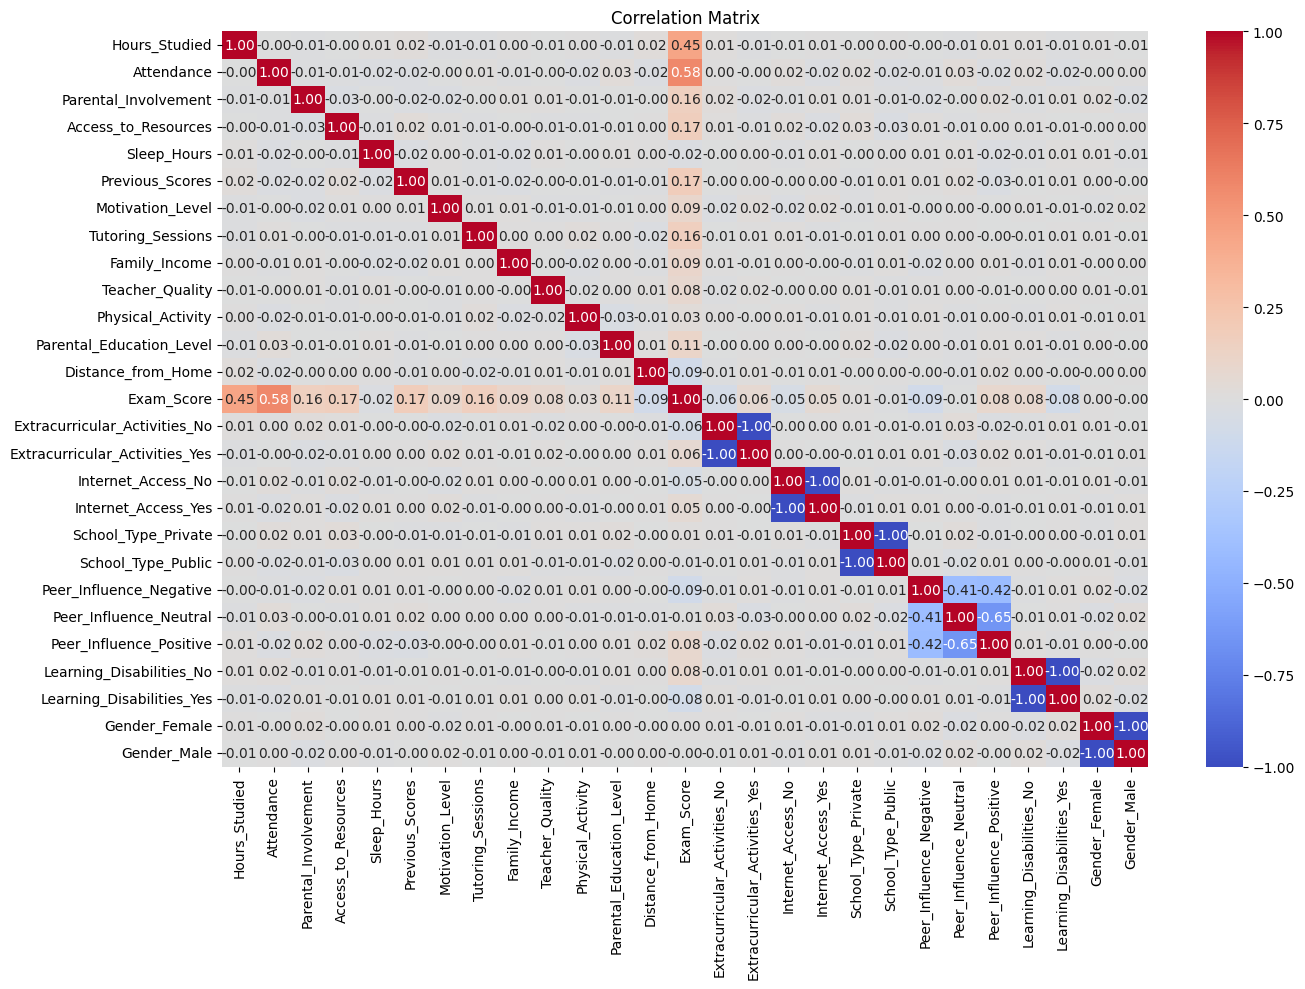

In [ ]:
# correlation heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(df_clean.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

Create train-test split with Sklearn

In [ ]:
# train test split
from sklearn.model_selection import train_test_split

#for feature importance later
feature_names = df_clean.drop('Exam_Score', axis=1).columns.tolist()

X = df_clean.drop('Exam_Score', axis=1)
y = df_clean['Exam_Score']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Scale data with standard scaler

In [ ]:
from sklearn.preprocessing import StandardScaler

# Fit on train, transform both
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## **Linear Regressions**

Linear Regression

In [ ]:
# create pandas dfs
X_train_pd = pd.DataFrame(X_train, columns=X.columns)
X_test_pd = pd.DataFrame(X_test, columns=X.columns)

In [ ]:
# Linear regression for baseline model with evaluation
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

baseline = LinearRegression()
baseline.fit(X_train_pd, y_train)

baseline_preds = baseline.predict(X_test_pd)

train_r2 = baseline.score(X_train_pd, y_train)
mse = mean_squared_error(y_test, baseline_preds)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, baseline_preds)

print(f"Train R² = {train_r2:.4f}")
print(f"MSE = {mse:.4f}")
print(f"RMSE = {rmse:.4f}")
print(f"Test R² = {r2:.4f}")

Train R² = 0.7185
MSE = 4.1581
RMSE = 2.0391
Test R² = 0.7324


In [ ]:
# feature importance by coefficient absolute value
importanceBase = pd.Series(baseline.coef_, index=feature_names).abs().sort_values(ascending=False)
print(importanceBase)

Attendance                        2.296280
Hours_Studied                     1.775172
Access_to_Resources               0.717625
Previous_Scores                   0.701687
Parental_Involvement              0.696145
Tutoring_Sessions                 0.595529
Family_Income                     0.422035
Parental_Education_Level          0.385713
Motivation_Level                  0.382674
Teacher_Quality                   0.332002
Distance_from_Home                0.308061
Peer_Influence_Negative           0.238641
Peer_Influence_Positive           0.210387
Physical_Activity                 0.206446
Extracurricular_Activities_No     0.138149
Extracurricular_Activities_Yes    0.138149
Learning_Disabilities_No          0.132881
Learning_Disabilities_Yes         0.132881
Internet_Access_No                0.118212
Internet_Access_Yes               0.118212
Sleep_Hours                       0.019713
Peer_Influence_Neutral            0.011803
School_Type_Private               0.011513
School_Type

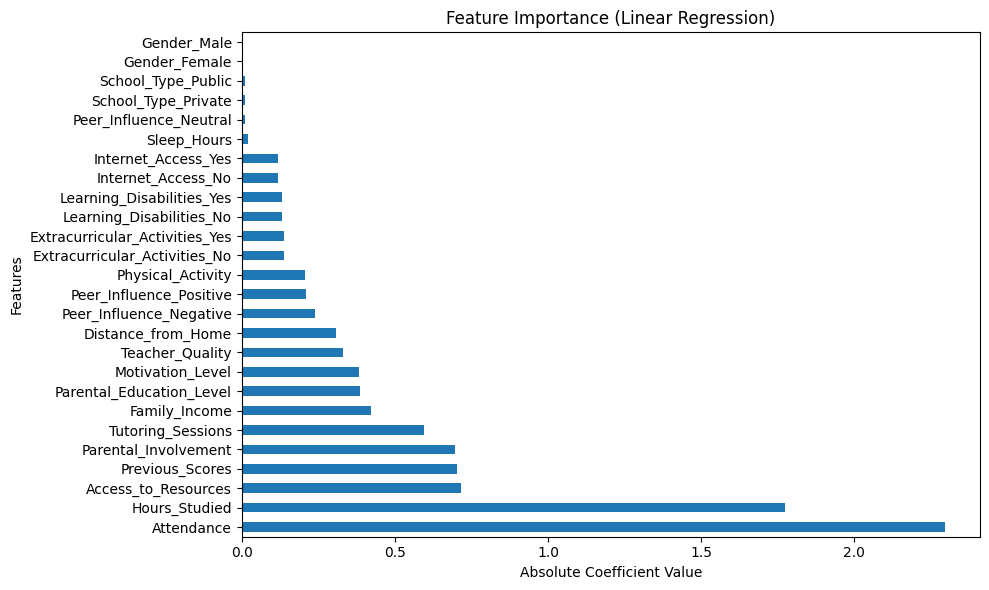

In [ ]:
# plot of feature importance
plt.figure(figsize=(10, 6))
importanceBase.plot(kind='barh')
plt.title("Feature Importance (Linear Regression)")
plt.xlabel("Absolute Coefficient Value")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

Feature Selection

In [ ]:
# feature selection
from sklearn.feature_selection import SequentialFeatureSelector

# new linear regression object
linreg = LinearRegression()

# create feature selection object and fit
feature_sel = SequentialFeatureSelector(linreg, n_features_to_select="auto", cv=5)
feature_sel.fit(X_train_pd, y_train)

# print selected features
selected_features = X.columns[feature_sel.get_support()]
print(f"{len(selected_features)} Stepwise selected features =", selected_features)

13 Stepwise selected features = Index(['Hours_Studied', 'Attendance', 'Parental_Involvement',
       'Access_to_Resources', 'Previous_Scores', 'Motivation_Level',
       'Tutoring_Sessions', 'Family_Income', 'Teacher_Quality',
       'Parental_Education_Level', 'Distance_from_Home',
       'Extracurricular_Activities_No', 'Peer_Influence_Positive'],
      dtype='object')


Reduced Linear Regression

In [ ]:
# create dfs with selected features
X_train_fs = X_train_pd[selected_features]
X_test_fs  = X_test_pd[selected_features]

# create new model
linreg_fs = LinearRegression()
linreg_fs.fit(X_train_fs, y_train)
fs_preds = linreg_fs.predict(X_test_fs)

# evaluate
train_r2_fs = linreg_fs.score(X_train_fs, y_train)
mse_fs = mean_squared_error(y_test, fs_preds)
rmse_fs = np.sqrt(mse_fs)
test_r2_fs = r2_score(y_test, fs_preds)

print(f"Train R² = {train_r2_fs:.4f}")
print(f"MSE = {mse_fs:.4f}")
print(f"RMSE = {rmse_fs:.4f}")
print(f"Test R² = {test_r2_fs:.4f}")

Train R² = 0.7049
MSE = 4.3089
RMSE = 2.0758
Test R² = 0.7227


Attendance                       2.300246
Hours_Studied                    1.776208
Access_to_Resources              0.703705
Previous_Scores                  0.699752
Parental_Involvement             0.693221
Tutoring_Sessions                0.597392
Family_Income                    0.420280
Motivation_Level                 0.386147
Parental_Education_Level         0.380535
Teacher_Quality                  0.327032
Peer_Influence_Positive          0.324724
Distance_from_Home               0.310105
Extracurricular_Activities_No    0.272601
dtype: float64


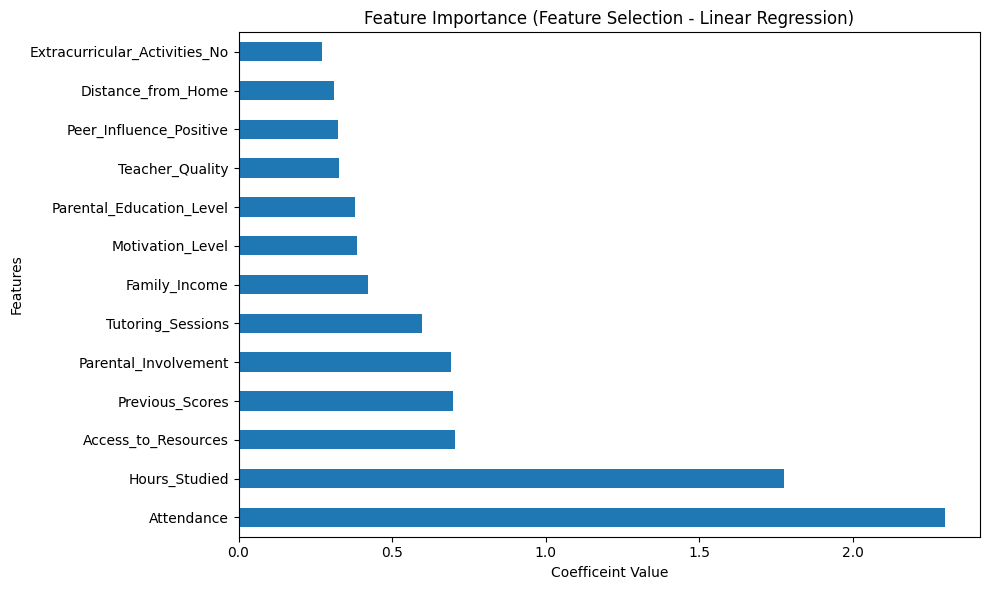

In [ ]:
importanceFS = pd.Series(linreg_fs.coef_, index=selected_features).abs().sort_values()
importanceFS = importanceFS.sort_values(ascending=False)

print(importanceFS)
plt.figure(figsize=(10, 6))
importanceFS.plot(kind='barh')

plt.title("Feature Importance (Feature Selection - Linear Regression)")
plt.xlabel("Coefficeint Value")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

## **Regularized Regressions**


---


Ridge Regression

In [ ]:
# ridge regression model
from sklearn.linear_model import RidgeCV
from sklearn.metrics import mean_squared_error, r2_score

# ridgeCV model
ridgeReg = RidgeCV(alphas=[0.01, 0.1, 1, 5, 10, 15, 20, 25, 50, 100], cv=5)
ridgeReg.fit(X_train_pd, y_train)
# find optimal alpha
print(f"Optimal Alpha = {ridgeReg.alpha_}")
# generate preds
RR_y_pred = ridgeReg.predict(X_test_pd)

# evaluation
RR_train_r2 = ridgeReg.score(X_train_pd, y_train)# how well model fits data
RR_mse = mean_squared_error(y_test, RR_y_pred)
RR_rmse = np.sqrt(RR_mse)
RR_test_r2 = r2_score(y_test, RR_y_pred)# how well model genralizes

print(f"Train R² = {RR_train_r2:.4f}")
print(f"MSE = {RR_mse:.4f}")
print(f"RMSE = {RR_rmse:.4f}")
print(f"R² = {RR_test_r2:.4f}")

Optimal Alpha = 20.0
Train R² = 0.7185
MSE = 4.1577
RMSE = 2.0391
R² = 0.7324


Attendance                        2.287080
Hours_Studied                     1.768053
Access_to_Resources               0.714498
Previous_Scores                   0.698757
Parental_Involvement              0.693019
Tutoring_Sessions                 0.593183
Family_Income                     0.420316
Parental_Education_Level          0.384259
Motivation_Level                  0.380946
Teacher_Quality                   0.330734
Distance_from_Home                0.307023
Peer_Influence_Negative           0.238003
Peer_Influence_Positive           0.209870
Physical_Activity                 0.205254
Extracurricular_Activities_Yes    0.137744
Extracurricular_Activities_No     0.137744
Learning_Disabilities_No          0.132731
Learning_Disabilities_Yes         0.132731
Internet_Access_No                0.117933
Internet_Access_Yes               0.117933
Sleep_Hours                       0.019850
Peer_Influence_Neutral            0.011816
School_Type_Private               0.011343
School_Type

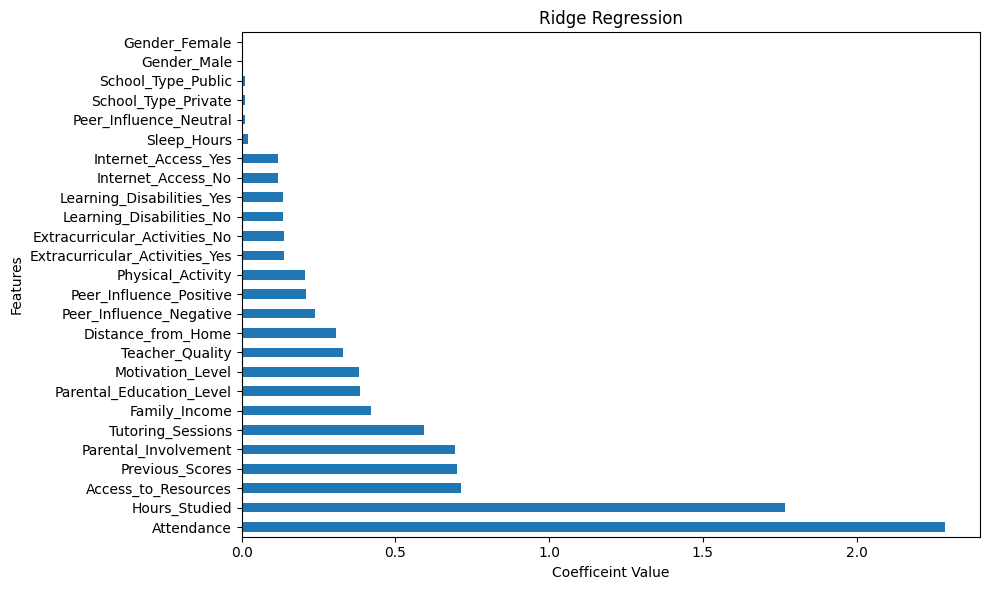

In [ ]:
#Ridge Regression Feature Importance
importanceRR = pd.Series(ridgeReg.coef_, index=feature_names).abs().sort_values()
importanceRR = importanceRR.sort_values(ascending=False)

print(importanceRR)
plt.figure(figsize=(10, 6))
importanceRR.plot(kind='barh')

plt.title("Ridge Regression")
plt.xlabel("Coefficeint Value")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

Lasso

In [ ]:
# lasso regression model
from sklearn.linear_model import LassoCV
from sklearn.metrics import mean_squared_error, r2_score

# lassoCV model
lassoReg = LassoCV(alphas=[0.00001, 0.0001, 0.001, 0.005, 0.01, 0.1, 1], cv=5, random_state=42)
lassoReg.fit(X_train_pd, y_train)
# find optimal alpha
print(f"Optimal Alpha = {lassoReg.alpha_}")
# generate preds
LR_y_pred = lassoReg.predict(X_test_pd)

# evaluation
LR_train_r2 = lassoReg.score(X_train_pd, y_train) # how well model fits data
LR_mse = mean_squared_error(y_test, LR_y_pred)
LR_rmse = np.sqrt(LR_mse)
LR_test_r2 = r2_score(y_test, LR_y_pred) # how well model generalizes

print(f"Train R² = {LR_train_r2:.4f}")
print(f"MSE = {LR_mse:.4f}")
print(f"RMSE = {LR_rmse:.4f}")
print(f"R² = {LR_test_r2:.4f}")

Optimal Alpha = 0.005
Train R² = 0.7184
MSE = 4.1567
RMSE = 2.0388
R² = 0.7325


In [ ]:
# what did lasso reduce to 0
dropped = X.columns[lassoReg.coef_ == 0]
print(dropped)

Index(['Peer_Influence_Neutral'], dtype='object')


Attendance                        2.290971e+00
Hours_Studied                     1.769869e+00
Access_to_Resources               7.119489e-01
Previous_Scores                   6.963930e-01
Parental_Involvement              6.906328e-01
Tutoring_Sessions                 5.908324e-01
Family_Income                     4.170216e-01
Parental_Education_Level          3.803639e-01
Motivation_Level                  3.776526e-01
Teacher_Quality                   3.269000e-01
Distance_from_Home                3.031061e-01
Extracurricular_Activities_No     2.710872e-01
Learning_Disabilities_No          2.609552e-01
Internet_Access_No                2.310713e-01
Peer_Influence_Negative           2.248856e-01
Peer_Influence_Positive           2.191907e-01
Physical_Activity                 2.004772e-01
School_Type_Private               1.792281e-02
Sleep_Hours                       1.492657e-02
Gender_Female                     3.803053e-04
Learning_Disabilities_Yes         4.820744e-15
Extracurricul

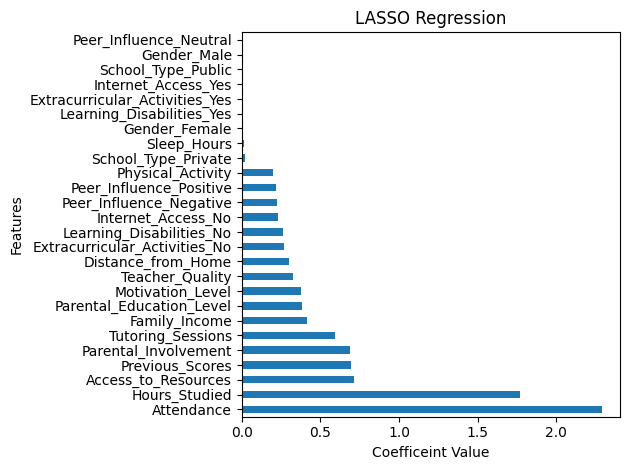

In [ ]:
#Lasso Regression Feature Importance
importanceLR = pd.Series(lassoReg.coef_, index=feature_names).abs().sort_values()
importanceLR = importanceLR.sort_values(ascending=False)

print(importanceLR)
importanceLR.plot(kind='barh')

plt.title("LASSO Regression")
plt.xlabel("Coefficeint Value")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

Elastic Net

In [ ]:
from sklearn.linear_model import ElasticNetCV
from sklearn.metrics import mean_squared_error, r2_score

elasticCV = ElasticNetCV(l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9, 0.95, 0.99, 1.0],
                         alphas=[0.00001, 0.0001, 0.001, 0.005, 0.01, 0.1, 1, 5, 10, 15, 20, 25, 50, 100],
                         cv=5,
                         random_state=42)

elasticCV.fit(X_train_pd, y_train)

# check optimal alpha and L1 ratio
print(f"Optimal Alpha = {elasticCV.alpha_}")
print(f"Optimal L1 Ratio = {elasticCV.l1_ratio_}\n")

# eval
EN_y_pred = elasticCV.predict(X_test_pd)
EN_train_r2 = elasticCV.score(X_train_pd, y_train)
EN_mse = mean_squared_error(y_test, EN_y_pred)
EN_rmse = np.sqrt(EN_mse)
EN_test_r2 = r2_score(y_test, EN_y_pred)

print(f"Train R² = {EN_train_r2:.4f}")
print(f"MSE = {EN_mse:.4f}")
print(f"RMSE = {EN_rmse:.4f}")
print(f"Test R² = {EN_test_r2:.4f}")

Optimal Alpha = 0.005
Optimal L1 Ratio = 1.0

Train R² = 0.7184
MSE = 4.1567
RMSE = 2.0388
Test R² = 0.7325


In [ ]:
dropped_EN = X.columns[elasticCV.coef_ == 0]
print(dropped_EN)

Index(['Peer_Influence_Neutral'], dtype='object')


Attendance                        2.290971e+00
Hours_Studied                     1.769869e+00
Access_to_Resources               7.119489e-01
Previous_Scores                   6.963930e-01
Parental_Involvement              6.906328e-01
Tutoring_Sessions                 5.908324e-01
Family_Income                     4.170216e-01
Parental_Education_Level          3.803639e-01
Motivation_Level                  3.776526e-01
Teacher_Quality                   3.269000e-01
Distance_from_Home                3.031061e-01
Extracurricular_Activities_No     2.710872e-01
Learning_Disabilities_No          2.609552e-01
Internet_Access_No                2.310713e-01
Peer_Influence_Negative           2.248856e-01
Peer_Influence_Positive           2.191907e-01
Physical_Activity                 2.004772e-01
School_Type_Private               1.792281e-02
Sleep_Hours                       1.492657e-02
Gender_Female                     3.803053e-04
Learning_Disabilities_Yes         4.820744e-15
Extracurricul

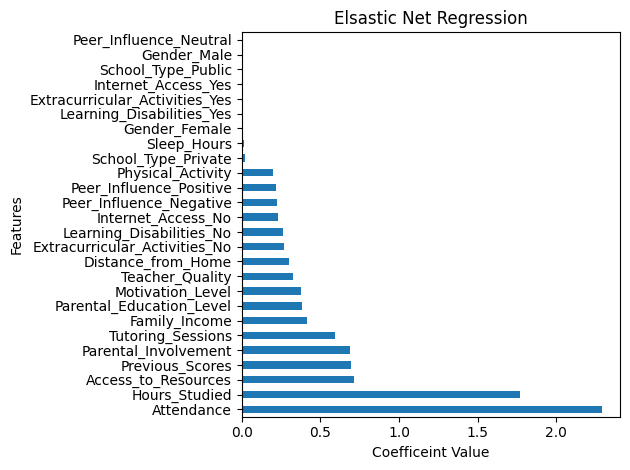

In [ ]:
#Elastic Net Regression Feature Importance
importanceEN = pd.Series(elasticCV.coef_, index=feature_names).sort_values().abs()
importanceEN = importanceEN.sort_values(ascending=False)

print(importanceEN)
importanceEN.plot(kind='barh')

plt.title("Elsastic Net Regression")
plt.xlabel("Coefficeint Value")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

Just became lasso again, ridge not helping

## Random Forest

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [ ]:
#Trying to fix overfitting. Second attempt:

In [ ]:

rf_2 = RandomForestRegressor(random_state=42, n_jobs=-1)

param_grid_2 = {
    'n_estimators': [300, 400, 500],
    'max_depth': [6, 8, 10],
    'min_samples_split': [20, 25, 30, 35],
    'min_samples_leaf': [12, 15, 20],
    'max_features': ['sqrt', 0.2, 0.3],
    'bootstrap': [True, False]
}

grid_search_2 = GridSearchCV(
    estimator=rf_2,
    param_grid=param_grid_2,
    cv=5,
    scoring='r2',
    verbose=1,
    n_jobs=-1
)

grid_search_2.fit(X_train_pd, y_train)

print(f"Best Parameters = {grid_search_2.best_params_}")
print(f"Best CV Score = {grid_search_2.best_score_:.4f}")

# Evaluate
rf_2_pred = grid_search_2.predict(X_test_pd)
rf_2_train_r2 = grid_search_2.score(X_train_pd, y_train)
rf_2_mse = mean_squared_error(y_test, rf_2_pred)
rf_2_rmse = np.sqrt(rf_2_mse)
rf_2_test_r2 = r2_score(y_test, rf_2_pred)

print(f"\nFinal Model Performance:")
print(f"Train R² = {rf_2_train_r2:.4f}")
print(f"MSE = {rf_2_mse:.4f}")
print(f"RMSE = {rf_2_rmse:.4f}")
print(f"Test R² = {rf_2_test_r2:.4f}")
print(f"R² Gap = {rf_2_train_r2 - rf_2_test_r2:.4f}")

Fitting 5 folds for each of 648 candidates, totalling 3240 fits
Best Parameters = {'bootstrap': False, 'max_depth': 10, 'max_features': 0.3, 'min_samples_leaf': 12, 'min_samples_split': 20, 'n_estimators': 500}
Best CV Score = 0.6157

Final Model Performance:
Train R² = 0.7235
MSE = 5.5687
RMSE = 2.3598
Test R² = 0.6416
R² Gap = 0.0819


Top 10 Most Important Features:
                 feature  importance
              Attendance    0.500349
           Hours_Studied    0.277797
         Previous_Scores    0.052009
     Access_to_Resources    0.033631
    Parental_Involvement    0.028813
       Tutoring_Sessions    0.024809
           Family_Income    0.011791
Parental_Education_Level    0.010536
        Motivation_Level    0.009188
      Distance_from_Home    0.006948


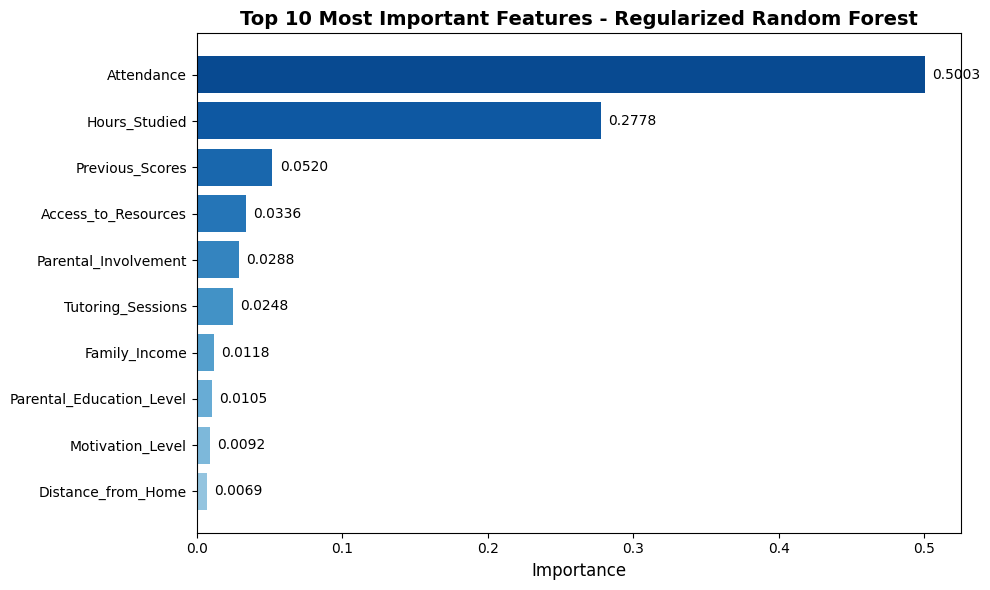

In [ ]:
rf_best = grid_search_2.best_estimator_

feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_best.feature_importances_
}).sort_values('importance', ascending=False)

print("Top 10 Most Important Features:")
print(feature_importance.head(10).to_string(index=False))

# Visualization
plt.figure(figsize=(10, 6))
top_features = feature_importance.head(10)
colors = plt.cm.Blues(np.linspace(0.4, 0.9, 10))[::-1]

plt.barh(range(len(top_features)), top_features['importance'].values, color=colors)
plt.yticks(range(len(top_features)), top_features['feature'].values)
plt.xlabel('Importance', fontsize=12)
plt.title('Top 10 Most Important Features - Regularized Random Forest', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()

# Add value labels
for i, v in enumerate(top_features['importance'].values):
    plt.text(v + 0.005, i, f'{v:.4f}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

#XGBoost

In [ ]:
#import packages
import xgboost as xgb
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [ ]:
#building model, max_depth=6
xgb_model1 = xgb.XGBRegressor(
    objective='reg:squarederror',
    random_state=42,
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='rmse'
)

#training the model
xgb_model1.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

xgb_preds = xgb_model1.predict(X_test)

#model evaluation
mse = mean_squared_error(y_test, xgb_preds)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, xgb_preds)
r2 = r2_score(y_test, xgb_preds)

print("XGBoost Model Performance:")
print(f"RMSE: {rmse:.2f}")
print(f"MAE:  {mae:.2f}")
print(f"R²:   {r2:.4f}")

#feature importance
xgb_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': xgb_model1.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 10 Most Important Features:")
print(xgb_importance.head(10))


XGBoost Model Performance:
RMSE: 2.22
MAE:  0.79
R²:   0.6828

Top 10 Most Important Features:
                           feature  importance
1                       Attendance    0.159697
0                    Hours_Studied    0.101866
3              Access_to_Resources    0.057590
2             Parental_Involvement    0.054294
8                    Family_Income    0.040603
5                  Previous_Scores    0.038878
21         Peer_Influence_Positive    0.038793
14  Extracurricular_Activities_Yes    0.036260
15              Internet_Access_No    0.035436
13   Extracurricular_Activities_No    0.035169


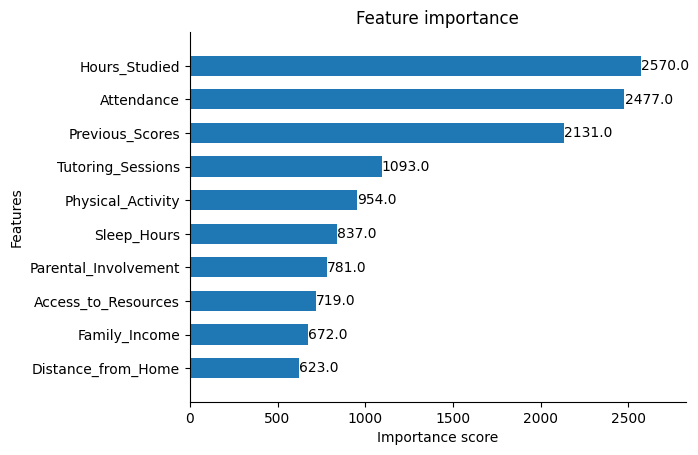

In [ ]:
#feature plot
xgb_model1.get_booster().feature_names = list(X.columns)
ax = xgb.plot_importance(xgb_model1, max_num_features=10, height=0.6)
ax.grid(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

Re-running model above but with max_depth=4 (as opposed to =6)

In [ ]:
#building model, max_depth=4
xgb_model2 = xgb.XGBRegressor(
    objective='reg:squarederror',
    random_state=42,
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='rmse'
)

#training the model
xgb_model2.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

xgb_preds = xgb_model2.predict(X_test)

#model evaluation
mse = mean_squared_error(y_test, xgb_preds)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, xgb_preds)
r2 = r2_score(y_test, xgb_preds)

print("XGBoost Model Performance:")
print(f"RMSE: {rmse:.2f}")
print(f"MAE:  {mae:.2f}")
print(f"R²:   {r2:.4f}")

#feature importance
xgb_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': xgb_model2.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 10 Most Important Features:")
print(xgb_importance.head(10))

XGBoost Model Performance:
RMSE: 2.13
MAE:  0.70
R²:   0.7093

Top 10 Most Important Features:
                    feature  importance
1                Attendance    0.220255
0             Hours_Studied    0.118444
3       Access_to_Resources    0.063851
2      Parental_Involvement    0.060062
8             Family_Income    0.044873
5           Previous_Scores    0.042062
19  Peer_Influence_Negative    0.040425
6          Motivation_Level    0.036022
7         Tutoring_Sessions    0.035494
21  Peer_Influence_Positive    0.034988


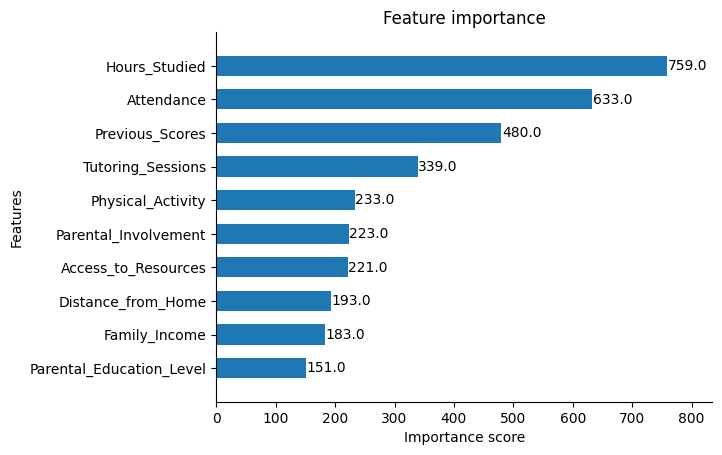

In [ ]:
#feature plot
xgb_model2.get_booster().feature_names = list(X.columns)
ax = xgb.plot_importance(xgb_model2, max_num_features=10, height=0.6)
ax.grid(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)


Running model once more but with min_child_weight to finetune/control overfitting if possible.

In [ ]:
xgb_model3 = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    min_child_weight=3,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

#training the model
xgb_model3.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

xgb_preds = xgb_model3.predict(X_test)

#model evaluation
mse = mean_squared_error(y_test, xgb_preds)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, xgb_preds)
r2 = r2_score(y_test, xgb_preds)

print("XGBoost Model Performance:")
print(f"RMSE: {rmse:.2f}")
print(f"MSE:  {mse:.2f}")
print(f"R²:   {r2:.4f}")

#feature importance
xgb_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': xgb_model3.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 10 Most Important Features:")
print(xgb_importance.head(10))

XGBoost Model Performance:
RMSE: 2.12
MSE:  4.49
R²:   0.7108

Top 10 Most Important Features:
                    feature  importance
1                Attendance    0.224725
0             Hours_Studied    0.108539
3       Access_to_Resources    0.066397
2      Parental_Involvement    0.062301
5           Previous_Scores    0.044824
8             Family_Income    0.043880
7         Tutoring_Sessions    0.037032
19  Peer_Influence_Negative    0.036236
21  Peer_Influence_Positive    0.035738
6          Motivation_Level    0.034914


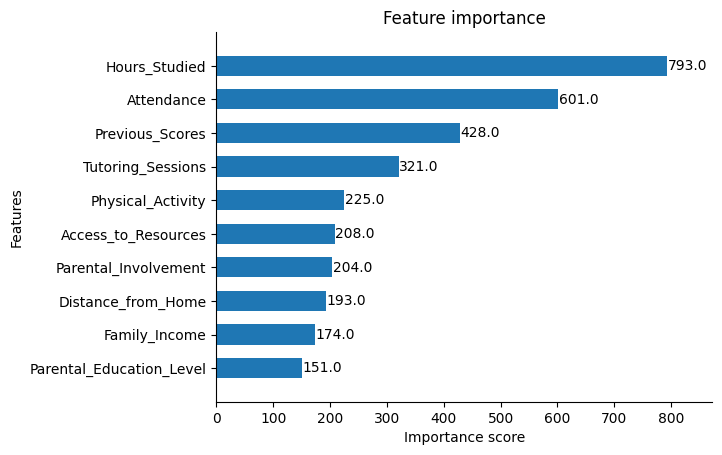

In [ ]:
#feature plot
xgb_model3.get_booster().feature_names = list(X.columns)
ax = xgb.plot_importance(xgb_model3, max_num_features=10, height=0.6)
ax.grid(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

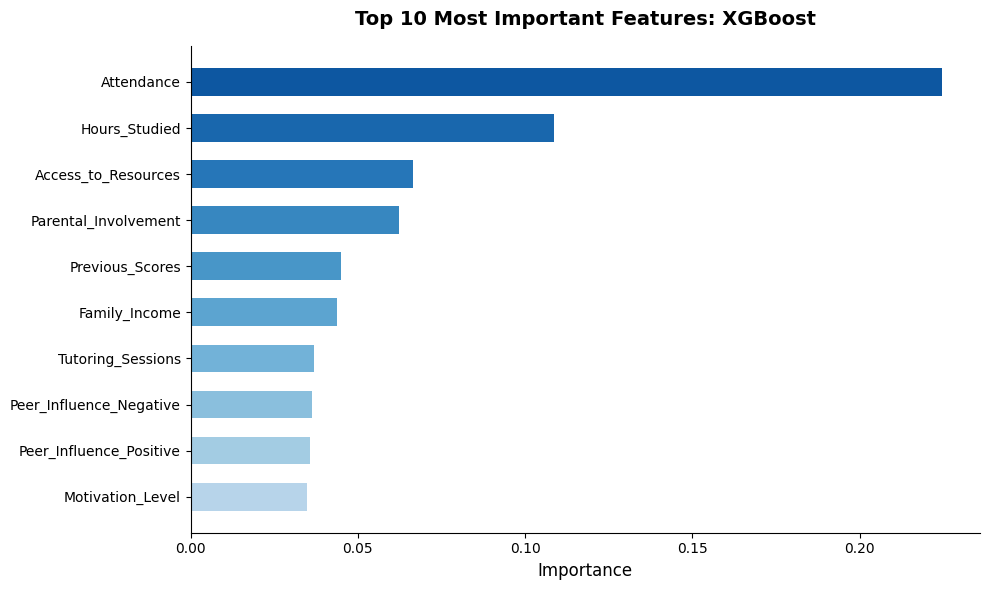

In [ ]:
#get top 10 features
top10 = xgb_importance.head(10).iloc[::-1]  # flip for horizontal bar chart

#create gradient colors (lighter = less important)
colors = plt.cm.Blues(np.linspace(0.3, 0.85, len(top10)))

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(top10['feature'], top10['importance'], color=colors, height=0.6)

#title and labels
ax.set_title('Top 10 Most Important Features: XGBoost', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Importance', fontsize=12)

#remove gridlines
ax.grid(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()